In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# SET WORKING DIRECTORY TO ROOT
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')


In [2]:
# LOAD MASSIVE RECOMMENDATIONS USING PYARROW ENGINE
recommendations_df = pd.read_csv('data/raw/recommendations.csv', engine='pyarrow')

# SHOW MISSING VALUES
print(recommendations_df.isnull().sum())


app_id            0
helpful           0
funny             0
date              0
is_recommended    0
hours             0
user_id           0
review_id         0
dtype: int64


In [ ]:
# EDA BEFORE CLEANING
print(f"Total de recomendaciones originales: {len(recommendations_df)}")

Total de recomendaciones originales: 41154794


In [4]:
# DROP ROWS WITH MISSING FOREIGN KEYS
cleaned_recs_df = recommendations_df.dropna(subset=['app_id', 'user_id'])

In [5]:
nulos_eliminados = len(recommendations_df) - len(cleaned_recs_df)
print(f"Recomendaciones eliminadas por falta de IDs: {nulos_eliminados}")

Recomendaciones eliminadas por falta de IDs: 0


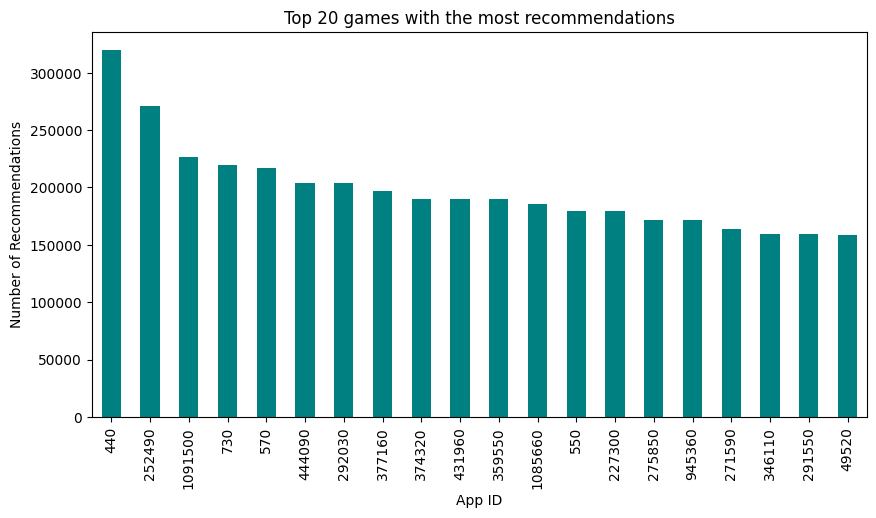

In [ ]:
# 1. ¿How are recommendations distributed by game? 
plt.figure(figsize=(10, 5))
top_games_recs = cleaned_recs_df['app_id'].value_counts().head(20)
top_games_recs.plot(kind='bar', color='teal')
plt.title('Top 20 games with the most recommendations')
plt.xlabel('App ID')
plt.ylabel('Number of Recommendations')
plt.show()

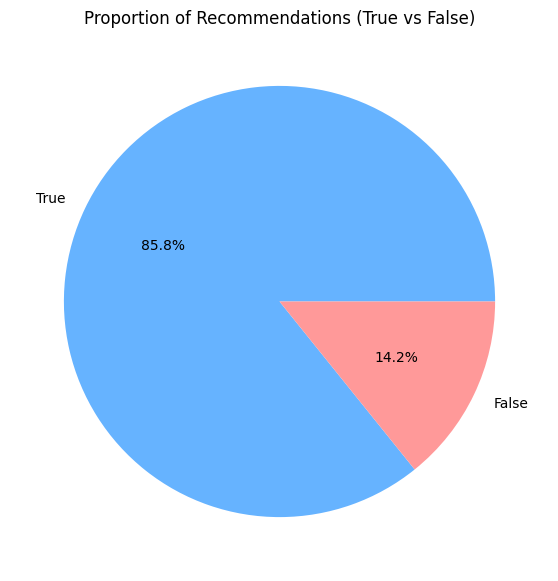

In [ ]:
# Pie or bar chart for recommendations
plt.figure(figsize=(7, 7))
cleaned_recs_df['is_recommended'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Proportion of Recommendations (True vs False)')
plt.ylabel('')
plt.show()

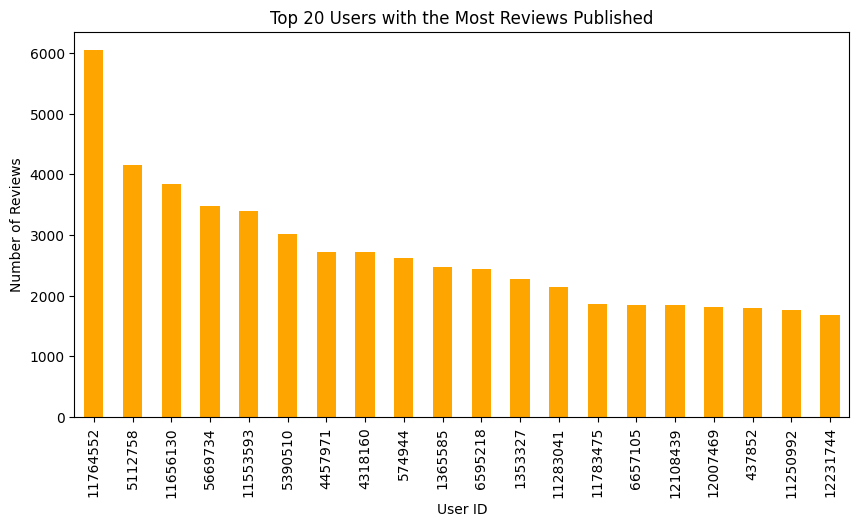

In [15]:
# Top 20 Users with the Most Reviews Published
user_activity = cleaned_recs_df['user_id'].value_counts().head(20)
plt.figure(figsize=(10, 5))
user_activity.plot(kind='bar', color='orange')
plt.title('Top 20 Users with the Most Reviews Published')
plt.xlabel('User ID')
plt.ylabel('Number of Reviews')
plt.show()

In [16]:
# SAVE CLEANED DATA
cleaned_recs_df.to_csv('data/processed/recommendations_cleaned.csv', index=False)
print("CLEANED RECOMMENDATIONS SAVED.")

CLEANED RECOMMENDATIONS SAVED.
